# MVP: *Machine Learning & Analytics* - Pós-Graduação PUC-RIO
### MVP apresentado como atividade final da Sprint Machine Learning & Analytics

**Autor:** Rogério dos Santos Ferreira  

**Data:** 27/08/2025

**Matrícula:** XXX

**Dataset:** [Hypertension Risk Prediction Dataset](https://www.kaggle.com/datasets/miadul/hypertension-risk-prediction-dataset)

Criação de modelo de Machine Learning destinado à classificação de risco de quadro de hipertensão.

Objetivo: Aplicação em dispositivos de monitoramento físico e aplicativos de treinamento físico.

Este conjunto de dados sintéticos, porém realistas, foi criado para auxiliar pesquisadores, cientistas de dados e entusiastas da saúde a analisar os fatores de risco associados à hipertensão (pressão alta). Ele contém 1.985 registros e 11 recursos significativos gerados com base em insights clínicos e padrões de dados de saúde pública.

| Variável | Descrição |
| :---: | --- |
| Age | Idade do paciente (em anos) |
| Salt_Intake | Ingestão diária de sal (em gramas) – um dos principais fatores que contribuem para a pressão alta |
| Stress_Score | Escala de 0 a 10 que mede o nível de estresse psicológico |
| BP_History | Estado pressórico anterior: Normal, Pré-hipertensão, Hipertensão |
| Sleep_Duration | Média de horas de sono por dia |
| BMI | Índice de Massa Corporal (medida de obesidade baseada em peso/altura) |
| Medication | Tipo de medicação: Nenhum, Betabloqueador, Diurético, Inibidor da ECA, Outro |
| Family_History | Histórico familiar de hipertensão: Sim/Não |
| Exercise_Level | Nível de atividade física: Baixo, Moderado, Alto |
| Smoking_Status | Se o paciente é fumante ou não fumante |
| Has_Hypertension | Variável-alvo: Indica a presença de hipertensão (Sim/Não) |

Fonte: https://www.kaggle.com/datasets/miadul/hypertension-risk-prediction-dataset

<a href="https://colab.research.google.com/github/rogerioferreira/MVP-Machine_Learnin-PUC-RIO/blob/main/notebooks/hypertension_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importação das bibliotecas necessárias para o projeto

In [42]:
# importação de bibliotecas básicas
import os
import joblib
import locale
import warnings
import pandas as pd
import plotly.express as px
import plotly.io as pio

# importação de métodos de tratamento
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

# importação de métodos de pré-processamento
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

# importação de modelos
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# importação de ensembles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

# importação de métricas de avaliação
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

# importação de ferramentas para construção de pipelines
from sklearn.pipeline import Pipeline

# configuração para não exibir warnings
warnings.filterwarnings("ignore")

# configuração de locale para pt-BR
locale.setlocale(locale.LC_ALL, "pt_BR.UTF-8")

# configuração para definição de tema, cores e tamanho padrão dos gráficos no Plotly
# Plotly themes ["plotly", "plotly_white", "plotly_dark", "ggplot2", "seaborn", "simple_white", "none"]
pio.templates.default = "plotly"

# atribui a configuração para exportação de gráficos do plotly
# ["notebook", "png"]
pio.renderers.default = "png"


# definição da semente aleatória visando a reprodutibilidade
SEED = 42

## Obtenção, análise e tratamento dos dados

In [43]:
data_path = "../dados/hypertension_dataset.csv"
url = "https://raw.githubusercontent.com/rogerioferreira/MVP-Machine_Learning-PUC-RIO/refs/heads/main/dados/hypertension_dataset.csv"

if os.path.exists(data_path):
    # caraga do dataset localmente, caso presente
    df = pd.read_csv(data_path, delimiter=",")
else:
    # caraga do dataset diretamente pelo Git Hub
    df = pd.read_csv(url, delimiter=",")

### Verificação da ocorrência de dados nulos no dataframe

Foi oservada a presença de valores nulos no registro do uso de medicação continuada para uma parcela significativa das ocorrências (40% dos casos), contudo, conforme descrição constante nos próprios metadados no Kaggle, o tipo de medicação subdivide-se em Nenhum, Betabloqueador, Diurético, Inibidor da ECA ou Outro, contudo, percebeu-se que os registros nulos referiam-se à ausência de medicação, desta forma, o procedimento adotado foi a substituição dos campos nulos com a atribuição do valor "No Medication", de forma a viabilizar de maneira adequada o emprego da informação no treinamento do modelo.

Tal decisão ampara-se na visão de Aurélien Géron que afirma que para dados categóricos, uma das abordagens para lidar com valores ausentes é a imputação, onde os valores faltantes são preenchidos. Uma vez que os dados categóricos não têm um valor numérico para o qual você possa calcular a média ou a mediana, o preenchimento pode ser feito com a categoria mais frequente (moda) ou com um valor constante, como 'desconhecido'. Uma abordagem comum para atributos categóricos é tratar os valores ausentes como uma categoria separada, como "Missing" ou "Unknown" (Géron, 2022).

In [44]:
# verificação da presença de valores nulos
df.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

In [45]:
# calculo do percentual de dados nulos
percentual = (df["Medication"].isnull().sum() / len(df)) * 100
print(f"Percentual de dados nulos: {percentual:.2f}%")

Percentual de dados nulos: 40.25%


In [46]:
# verificação das categorias existentes na coluna Medication
df["Medication"].unique().tolist()

[nan, 'ACE Inhibitor', 'Other', 'Beta Blocker', 'Diuretic']

In [47]:
# atribuição de informação de não uso de medicação para os registros nulos
df["Medication"].fillna("No Medication", inplace=True)

### Verificação de dados duplicados no dataframe

A existência de dados duplicados em um dataframe de treinamento de machine learning pode ter um impacto significativo nos modelos. A duplicação pode distorcer a importância de certas observações, fazendo com que o modelo considere essas instâncias mais importantes do que realmente são. Isso pode levar a um viés no treinamento, onde o modelo dá mais peso a padrões repetidos, afetando sua capacidade de generalizar para novos dados (Mukhopadhyay, 2018).

Neste sentido, foi realizada a averiguação quanto a existência de ocorrências duplicadas no conjunto de dados, contudo, não foram observadas ocorrências de duplicidades nos mesmos.

In [48]:
# verificação da presença de dados duplicados
print(f"Identificação de duplicatas: {df.duplicated().any()}")

# verificação da quantidade de entradas duplicadas no dataframe
print(f"Quantidade de registro duplicados: {df.duplicated().sum()}")

Identificação de duplicatas: False
Quantidade de registro duplicados: 0


### Verificação da existência de outliers

Outliers são pontos de dados com valores muito diferentes da maioria dos outros pontos do conjunto de dados. Eles podem ser observações genuínas, mas também podem ser resultado de erros de medição, erros de entrada de dados ou problemas no processo de coleta. A existência de outliers pode afetar o desempenho de certos algoritmos, especialmente os que são sensíveis a variações nos dados, como a regressão linear e as máquinas de vetores de suporte (SVMs). Esses pontos extremos podem influenciar o modelo a aprender um padrão que não representa a maioria dos dados, levando a um desempenho ruim em novos dados (BROWNLEE, 2016).

Contudo, Nem todos os dados que parecem estar fora de uma distribuição normal de dados são necessariamente outliers. É importante entender a causa do valor atípico para decidir como tratá-lo. Por exemplo, um valor pode ser extremo, mas ser uma observação legítima e importante para o seu modelo (GÉRON, 2022).

Desta forma, foram analisadas as variáveis Idade, Ingestão Diária de Sal, Escala de Estresse Psicológico, Horas de Sono e Índice de Massa Corporal quanto a ocorrência de outliers, por tratarem-se de variáveis não categóricas, chegando-se às seguintes conclusões:

As variáveis Idade e Escala de Estresse Psicológico não apresentaram nenhuma ocorrência fora dos limites dos limites máximos e mínimos com base nos quartis, afastando automaticamente a hipótese da existência de outliers para estes casos.

As variáveis Ingestão Diária de Sal e Horas de Sono, apesar de apresentarem valores inferiores e superiores aos limites mínimo e máximo do primeiro e do terceiro quartis, respectivamente, observa-se que os mesmos encontram-se muito próximos às áreas limítrofes e com valores coerentes às variáveis, não havendo dispersão significativa, optando-se, desta forma, pelo afastamento da hipótese da caracterização dos mesmo como outliers.

Por fim, na análise da variável Índice de Massa Corporal, observa-se uma dispersão um pouco maior dos valores inferiores e superiores aos limites mínimo e máximo do primeiro e do terceiro quartis, respectivamente, contudo, entende-se que os mesmos são valores acitáveis para ocorrência de índice de massa corporal (cisnes negros), devendo os mesmos serem empregados como valores válidos ao invés de serem descartados, optando-se, desta forma, pelo afastamento da hipótese da caracterização dos mesmo como outliers.

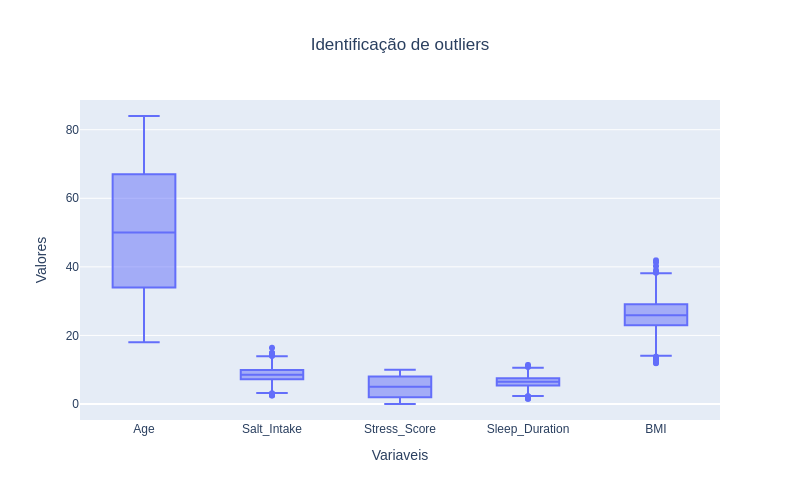

In [49]:
# identificação de outliers nas variáveis não categóricas ou binárias
features = ["Age", "Salt_Intake", "Stress_Score", "Sleep_Duration", "BMI"]


# boxplot para visualização de outliers
fig = px.box(
    df[features],
    y=features,
    title="Identificação de outliers",
    width=800,
    height=500,
)
fig.update_layout(
    xaxis_title="Variaveis",
    yaxis_title="Valores",
    title_x=0.5,
)
fig.show()

In [50]:
# exibição dos valores mínimos e máximos das variáveis analisadas
features = ["Salt_Intake", "Sleep_Duration", "BMI"]

for feature in features:
    print(
        f"{feature:<14} - Min: {df[feature].min():>5.2f}   Max: {df[feature].max():>5.2f}"
    )

Salt_Intake    - Min:  2.50   Max: 16.40
Sleep_Duration - Min:  1.50   Max: 11.40
BMI            - Min: 11.90   Max: 41.90


In [51]:
df[features].describe()

,Salt_Intake,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000
mean,8.531688,6.452242,26.015315
std,1.994907,1.542207,4.512857
min,2.500000,1.500000,11.900000
25%,7.200000,5.400000,23.000000
50%,8.500000,6.500000,25.900000
75%,9.900000,7.500000,29.100000
max,16.400000,11.400000,41.900000


### Tratamento de variáveis categóricas e variáveis numéricas

Variáveis categóricas devem ser transformadas em variáveis numéricas porque a maioria dos algoritmos de machine learning trabalha exclusivamente com números. Isso se aplica tanto a variáveis categóricas ordinais, que possuem uma ordem intrínseca (como “pequeno”, “médio”, “grande”), quanto a variáveis nominais, que não possuem nenhuma ordem (como “vermelho”, “azul”, “verde”) (Géron, 2022).

Variáveis ordinais, por terem uma ordem, podem ser convertidas para números inteiros. Por exemplo, a variável “tamanho” pode ser mapeada para 0 para “pequeno”, 1 para “médio” e 2 para “grande”. A classe OrdinalEncoder do Scikit-Learn é recomendada para essa tarefa, pois atribui um número inteiro único a cada categoria (Géron, 2022).

Para variáveis nominais, a simples conversão para números inteiros pode confundir os algoritmos, fazendo-os supor que os valores mais altos são "melhores" do que os mais baixos. Para evitar esse problema, o método mais comum é o One-Hot Encoding. Este método cria uma nova coluna binária (com valores 0 ou 1) para cada categoria da variável original (Géron, 2022).

Como técnica de tratamento das variáveis Estado Pressórico Anterior e Tipo de Medicação, por tratarem-se de variáveis categóricas não binárias, optou-se pelo emprego do método "One Hot Encoder", criando-se uma coluna binária para cada ocorrência de tipo categórico na variável. Além disso, ouptou-se pela remoção da primeira ocorrência na criação das novas variáveis binárias, de forma a evitar a multicolinearidade nos dados resultantes.

Já para as variáveis categóricas binárias Histórico Familiar de Hipertensão, Fumante ou não Fumante e Presença de Hipertensão (variável-alvo), optou-se pela adoção do método "Ordinal Encoder" em virtude da característica binária das mesmas, atribuindo-se o valor 0 para "não" e 1 para "sim".

Para a variável Nível de Atividade Física, apesar da mesma não se tratar de uma variável categórica binária, optou-se pelo emprego do método "Ordinal Encoder", ordenando-se suas categorias em Baixo, Moderado e Alto, de forma a dar sentido de sequêcia, atribuindo-se para as mesmas os valores 0, 1 e 2, respctivamente.

In [52]:
# realização da transformação de variáveis categóricas não binárias
# drop="first" - evita a multicolinearidade, removendo a primeira categoria
features = ["BP_History", "Medication"]
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")

one_hot_features = one_hot.fit_transform(df[features])
df_one_hot = pd.DataFrame(
    one_hot_features,
    columns=one_hot.get_feature_names_out(features),
)

df.drop(columns=features, inplace=True)  # remoção das features categóricas
df = pd.concat([df_one_hot, df], axis=1)  # concatenação dos dados transformados

del df_one_hot  # exclusão do dataframe temporário

In [53]:
# realização da transformação de variáveis categóricas binárias ou com sentido ordinal
features = []

features.append(("Family_History", ["No", "Yes"]))
features.append(("Smoking_Status", ["Non-Smoker", "Smoker"]))
features.append(("Has_Hypertension", ["No", "Yes"]))
features.append(("Exercise_Level", ["Low", "Moderate", "High"]))


for feature, ordem in features:
    one_hot = OrdinalEncoder(handle_unknown="error", categories=[ordem])

    one_hot_feature = one_hot.fit_transform(df[[feature]])
    df_one_hot = pd.DataFrame(
        one_hot_feature,
        columns=[feature],
    )

    df.drop(columns=feature, inplace=True)  # remoção das features categóricas
    df = pd.concat([df_one_hot, df], axis=1)  # concatenação dos dados transformados

    del df_one_hot  # exclusão do dataframe temporário

Converter variáveis do tipo inteiro para ponto flutuante é uma etapa necessária no pré-processamento de dados para o machine learning. Muitos algoritmos de machine learning, como os da biblioteca Scikit-Learn, exigem que todas as features de entrada sejam do tipo float64. Essa padronização evita erros e garante que as operações matemáticas internas dos algoritmos funcionem corretamente (Géron, 2022).

Sendo assim, as variáveis numéricas Idade e Escala de Estresse Psicológico foram transformadas de valores inteiros de 64 bits para valores de ponto flutuante de 64 bits.

In [54]:
# conversão das features com valores inteiros para ponto flutuante
df[["Age", "Stress_Score"]] = df[["Age", "Stress_Score"]].astype("float64")

# verificação da estrutura final do dataset após tratamento das variaveis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Exercise_Level              1985 non-null   float64
 1   Has_Hypertension            1985 non-null   float64
 2   Smoking_Status              1985 non-null   float64
 3   Family_History              1985 non-null   float64
 4   BP_History_Normal           1985 non-null   float64
 5   BP_History_Prehypertension  1985 non-null   float64
 6   Medication_Beta Blocker     1985 non-null   float64
 7   Medication_Diuretic         1985 non-null   float64
 8   Medication_No Medication    1985 non-null   float64
 9   Medication_Other            1985 non-null   float64
 10  Age                         1985 non-null   float64
 11  Salt_Intake                 1985 non-null   float64
 12  Stress_Score                1985 non-null   float64
 13  Sleep_Duration              1985 

In [55]:
df.head()

,Exercise_Level,Has_Hypertension,Smoking_Status,Family_History,BP_History_Normal,BP_History_Prehypertension,Medication_Beta Blocker,Medication_Diuretic,Medication_No Medication,Medication_Other,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,69.0,8.0,9.0,6.4,25.8
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,32.0,11.7,10.0,5.4,23.4
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,78.0,9.5,3.0,7.1,18.7
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,10.0,10.0,4.2,22.1
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,41.0,9.8,1.0,5.8,16.2


### Verificação de correlação entre as variáveis independentes

A verificação da correlação entre as variáveis independentes é um passo crucial na análise exploratória de dados, pois a existência de uma alta correlação, conhecida como multicolinearidade, pode afetar negativamente o treinamento de modelos de machine learning, especialmente os modelos lineares como a regressão linear e a regressão logística. A multicolinearidade pode fazer com que o modelo se ajuste muito bem aos dados de treinamento (overfitting), mas tenha um desempenho ruim em novos dados, pois o modelo pode ter aprendido os padrões de forma errada (Géron, 2022).

Calcuando-se a correlação entre as variáveis independentes observa-se uma incidência moderada de correlação entre as variáveis "BP_History_Prehypertension" e "BP_History_Normal", bem como entre as variáveis "Medication_No Medication" e "Medication_Beta Blocker", o que nos leva a considerar a necessidade de aplicação de técnica de redução de dimensionalidade ou de seleção de características.

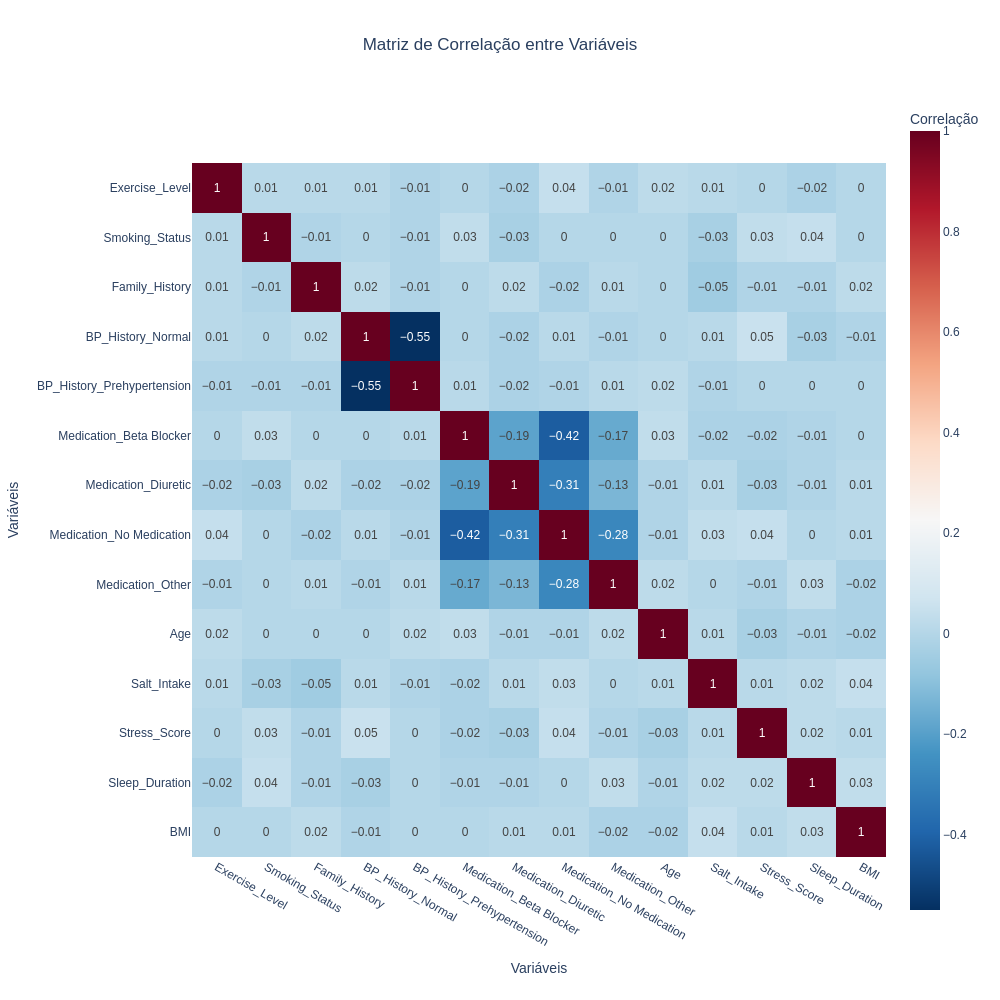

In [56]:
# verificação da correlação entre as variáveis
corr_matrix = df.drop(columns="Has_Hypertension").corr().round(2)

fig = px.imshow(
    corr_matrix,
    labels=dict(x="Variáveis", y="Variáveis", color="Correlação"),
    x=corr_matrix.columns,
    y=corr_matrix.index,
    color_continuous_scale="RdBu_r",
    title="Matriz de Correlação entre Variáveis",
    text_auto=True,
)
fig.update_layout(
    title_x=0.5,
    height=1000,
    width=1000,
)
fig.show()

### Preparação dos dados para seleção de modelos

Nesta etapa foi realizada a separação das variáveis independentes (características) da variável dependente (variavel-alvo).

In [57]:
# Separação em bases de treino e teste (holdout)
X = df.drop(columns="Has_Hypertension")
y = df["Has_Hypertension"]

### Aplicação de técnica de redução de dimencionalidade

Em virtude da observação de correlação moderada entre algumas variáveis independentes optou-se pelo emprego da técnica de redução da dimensionalidade PCA antes da avaliação dos modelos, reduzindo-se o conjunto de dados de 13 para 10 caractrerísticas, diminuindo a complexidade do modelo e reduzindo a probabilidade de ajuste excessivo ao dados de treinamento.

A aplicação de técnicas de redução de dimensionalidade em um conjunto de dados para machine learning oferece diversas vantagens importantes como a diminuição do overfitting, aceleração do treinamento, melhora do desempenho do modelo e o combate à maldição da dimensionalidade. Ao reduzir o número de variáveis de entrada, o modelo se torna menos complexo. Isso diminui a chance de o modelo se ajustar em excesso (overfitting) aos dados de treinamento, permitindo que ele generalize melhor para novos dados e faça previsões mais precisas. A redução de dimensionalidade pode ajudar a mitigar os efeitos desse fenômeno, conhecido como "Maldição da Dimensionalidade" (Géron, 2022).

Esta técnica se concentra em criar um conjunto menor de recursos, frequentemente chamado de "nova dimensionalidade", ao extrair informações de um conjunto maior de atributos existentes. A redução de dimensionalidade não descarta atributos; em vez disso, ela cria novas características que são combinações ou projeções dos atributos originais (Gallatin & Albon, 2023).

Análise de Componentes Principais (PCA) é uma técnica de redução de dimensionalidade que pode ser usada para combinar as variáveis correlacionadas em um novo conjunto de variáveis não correlacionadas, mantendo a maior parte da informação original (Mukhopadhyay, 2018).

In [58]:
# aplicação de ténica de redução de dimensionalidade
pca = PCA(
    n_components=10, random_state=SEED
)
X = pca.fit_transform(X)

X.shape

(1985, 10)

In [59]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,18.636630,-0.059567,4.122670,-0.591181,-0.068882,-0.693672,0.694687,0.581366,0.557507,-0.246448
1,-18.348427,-2.590233,4.982646,3.173497,-1.223384,-0.724955,0.609392,0.625122,-0.388334,-0.271584
2,27.711071,-7.153238,-1.698593,1.152911,0.713636,0.294372,0.663836,0.678562,-0.418289,-0.294828
3,-12.341705,-3.903931,4.990076,1.443331,-2.331547,-0.784204,-0.173863,-0.175933,-0.449113,-0.309238
4,-9.260142,-9.904515,-3.884488,1.513475,-0.562353,0.232226,-0.801462,-0.238677,-0.419820,-0.325777
...,...,...,...,...,...,...,...,...,...,...
1980,5.692324,-1.017693,-4.920739,1.720247,0.061566,-0.744155,0.697576,-0.389514,0.504657,-0.329142
1981,-21.282269,-9.234782,-0.946356,0.631847,0.489357,1.328606,-0.061374,0.533993,0.587148,-0.215768
1982,13.675911,-7.040645,4.165849,-2.560491,-0.749021,0.273828,0.631042,-0.286368,0.451602,-0.309991
1983,-15.377990,3.132687,2.904298,-1.145416,1.701885,0.334053,-0.711840,0.584010,0.604035,-0.258562


Nesta etapa os dados foram separados em conjuntos de treino e teste, visando o treinamento do modelo e a aferição da precisão do mesmo com dados não empregados anteriormente. Além disto, foram definidas os parâmetros de quatitativo de partições empregadas para a validação cruzada entre os modelos e o método de aferição do percentual de ajuste do modelo, selecionando nesta etapa o método de acurácia para avaliação.

In [60]:
# separação dos conjuntos de treinamento e de teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)  # faz a divisão

# definição de parâmetros para a validação cruzada
num_particoes = 10  # número de folds da validação cruzada (3, 5, 10)
scoring = "accuracy"

kfold = KFold(
    n_splits=num_particoes, shuffle=True, random_state=SEED
)  # faz o particionamento em K folds

## Modelagem e inferência

### Avaliação prévia dos modelos

A validação cruzada (cross-validation) é uma técnica essencial para avaliar o desempenho de um modelo de machine learning, e sua principal vantagem é a divisão dos dados de treinamento em várias partes, ou "dobras" (folds). Essa abordagem oferece benefícios significativos em comparação com uma única divisão de dados, como a partição simples entre treinamento e teste, como avaliação de desempenho mais robusta, uso completo dos dados de treinamento e detecção de overfitting (Géron, 2022).

In [61]:
# criação de lista para armazenar os modelos
models = []

# definição de parâmetros do classificador
num_trees = 100
max_features = X.shape[1]  # número de features após PCA

# definição dos modelos para teste
models.append(("LR", LogisticRegression(random_state=SEED, max_iter=200)))
models.append(("KNN", KNeighborsClassifier()))
models.append(("DT", DecisionTreeClassifier(random_state=SEED)))
models.append(("GNB", GaussianNB()))
models.append(("SVM", SVC(random_state=SEED)))


models.append(("ADA", AdaBoostClassifier(random_state=SEED, n_estimators=num_trees)))
models.append(
    (
        "RF",
        RandomForestClassifier(
            random_state=SEED, n_estimators=num_trees, max_features=max_features
        ),
    )
)
models.append(
    (
        "ET",
        ExtraTreesClassifier(
            random_state=SEED, n_estimators=num_trees, max_features=max_features
        ),
    )
)
models.append(
    (
        "BAG",
        BaggingClassifier(
            random_state=SEED, n_estimators=num_trees, max_features=max_features
        ),
    )
)
models.append(
    (
        "GB",
        GradientBoostingClassifier(
            random_state=SEED, n_estimators=num_trees, max_features=max_features
        ),
    )
)


# criação de listas para armazenar os resultados e os nomes dos modelos
results = []
names = []

# criação de listas para armazenar as médias e os desvios padrão para geração de dataframe
means = []
std = []


# métricas mais relevantes para seleção dos modelos:
# Acurácia (accuracy): A proporção de predições corretas sobre o total de predições.
# Precisão (precision): Dos casos que o modelo previu como positivos, quantos eram realmente positivos.
# Sensibilidade (recall): Dos casos que eram realmente positivos, quantos o modelo conseguiu identificar.
# Pontuação F1 (f1-score): É a média harmônica entre precisão e recall. É uma métrica útil quando as classes estão desbalanceadas.
# Curva ROC e AUC: Medem a capacidade do modelo de distinguir entre as classes.
for name, model in models:

    print(" " * 80, end="\r")
    print(f"Treinando o modelo: {name}", end="\r")
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)

    results.append(cv_results)
    names.append(name)
    means.append(cv_results.mean())
    std.append(cv_results.std())


# geraão do dataframe de resultados
df_results = pd.DataFrame(
    {
        "Modelo": names,
        "Média": means,
        "Desvio Padrão": std,
    }
)

# exibição dos resultados
print(df_results.set_index("Modelo").sort_values("Média", ascending=False))

           Média  Desvio Padrão                                                 
Modelo                         
ADA     0.989292       0.007479
GB      0.974811       0.014615
ET      0.920671       0.015387
BAG     0.916878       0.010815
RF      0.914350       0.017878
DT      0.877207       0.022014
GNB     0.773919       0.026388
LR      0.720369       0.029810
SVM     0.677585       0.030739
KNN     0.642306       0.043155


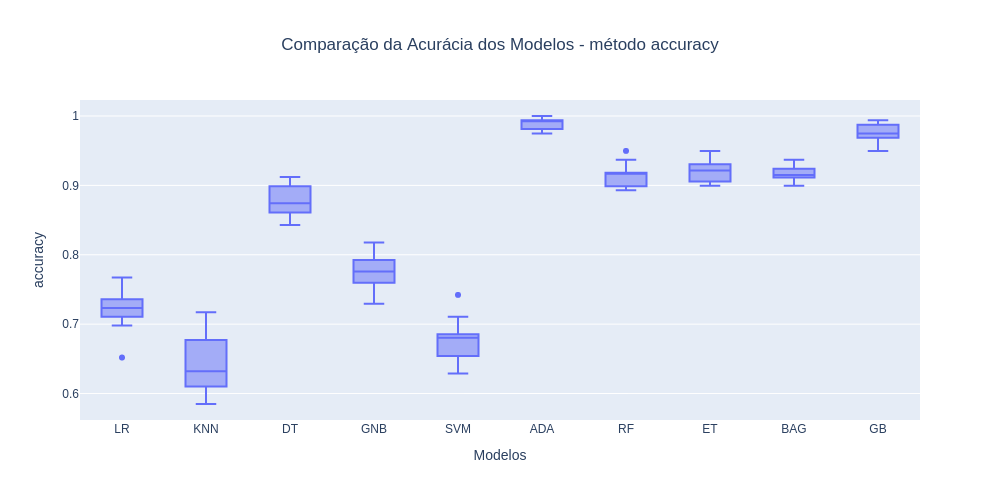

In [19]:
# boxplot de comparação dos modelos
fig = px.box(
    data_frame=pd.DataFrame(
        data=results, index=names
    ).transpose(),  # resultados individuais em linhas (index)
    y=names,
    title=f"Comparação da Acurácia dos Modelos - método {scoring}",
    width=1000,
    height=500,
)
fig.update_layout(
    xaxis_title="Modelos",
    yaxis_title=scoring,
    title_x=0.5,
)
fig.show()

### Avaliação dos modelos com dados originais, padronizados, normalizados e robustos

In [41]:
# criação de listas para armazenar os pipelines e os resultados
pipelines = []
results = []
names = []

# criação de listas para armazenar as médias e os desvios padrão para geração de dataframe
means = []
std = []

# definição dos elementos do pipeline

# algoritmos empregados
lr = ("LR", LogisticRegression(random_state=SEED, max_iter=200))
knn = ("KNN", KNeighborsClassifier())
dt = ("DT", DecisionTreeClassifier(random_state=SEED))
gnb = ("GNB", GaussianNB())
svm = ("SVM", SVC(random_state=SEED))
ada = ("ADA", AdaBoostClassifier(random_state=SEED, n_estimators=num_trees))
rf = (
    "RF",
    RandomForestClassifier(
        random_state=SEED, n_estimators=num_trees, max_features=max_features
    ),
)
et = (
    "ET",
    ExtraTreesClassifier(
        random_state=SEED, n_estimators=num_trees, max_features=max_features
    ),
)
bag = (
    "BAG",
    BaggingClassifier(
        random_state=SEED, n_estimators=num_trees, max_features=max_features
    ),
)
gb = (
    "GB",
    GradientBoostingClassifier(
        random_state=SEED, n_estimators=num_trees, max_features=max_features
    ),
)

# transformações empregadas
standard_scaler = ("StandardScaler", StandardScaler())
min_max_scaler = ("MinMaxScaler", MinMaxScaler())
robust_scaler = ("RobustScaler", RobustScaler())

# definição dos pipelines
pipelines.append(("LR-orig", Pipeline(steps=[lr])))
pipelines.append(("LR-std", Pipeline(steps=[standard_scaler, lr])))
pipelines.append(("LR-norm", Pipeline(steps=[min_max_scaler, lr])))
pipelines.append(("LR-rob", Pipeline(steps=[robust_scaler, lr])))

pipelines.append(("KNN-orig", Pipeline(steps=[knn])))
pipelines.append(("KNN-std", Pipeline(steps=[standard_scaler, knn])))
pipelines.append(("KNN-norm", Pipeline(steps=[min_max_scaler, knn])))
pipelines.append(("KNN-rob", Pipeline(steps=[robust_scaler, knn])))

pipelines.append(("DT-orig", Pipeline(steps=[dt])))
pipelines.append(("DT-std", Pipeline(steps=[standard_scaler, dt])))
pipelines.append(("DT-norm", Pipeline(steps=[min_max_scaler, dt])))
pipelines.append(("DT-rob", Pipeline(steps=[robust_scaler, dt])))

pipelines.append(("GNB-orig", Pipeline(steps=[gnb])))
pipelines.append(("GNB-std", Pipeline(steps=[standard_scaler, gnb])))
pipelines.append(("GNB-norm", Pipeline(steps=[min_max_scaler, gnb])))
pipelines.append(("GNB-rob", Pipeline(steps=[robust_scaler, gnb])))

pipelines.append(("SVM-orig", Pipeline(steps=[svm])))
pipelines.append(("SVM-std", Pipeline(steps=[standard_scaler, svm])))
pipelines.append(("SVM-norm", Pipeline(steps=[min_max_scaler, svm])))
pipelines.append(("SVM-rob", Pipeline(steps=[robust_scaler, svm])))

pipelines.append(("ADA-orig", Pipeline(steps=[ada])))
pipelines.append(("ADA-std", Pipeline(steps=[standard_scaler, ada])))
pipelines.append(("ADA-norm", Pipeline(steps=[min_max_scaler, ada])))
pipelines.append(("ADA-rob", Pipeline(steps=[robust_scaler, ada])))

pipelines.append(("RF-orig", Pipeline(steps=[rf])))
pipelines.append(("RF-std", Pipeline(steps=[standard_scaler, rf])))
pipelines.append(("RF-norm", Pipeline(steps=[min_max_scaler, rf])))
pipelines.append(("RF-rob", Pipeline(steps=[robust_scaler, rf])))

pipelines.append(("ET-orig", Pipeline(steps=[et])))
pipelines.append(("ET-std", Pipeline(steps=[standard_scaler, et])))
pipelines.append(("ET-norm", Pipeline(steps=[min_max_scaler, et])))
pipelines.append(("ET-rob", Pipeline(steps=[robust_scaler, et])))

pipelines.append(("BAG-orig", Pipeline(steps=[bag])))
pipelines.append(("BAG-std", Pipeline(steps=[standard_scaler, bag])))
pipelines.append(("BAG-norm", Pipeline(steps=[min_max_scaler, bag])))
pipelines.append(("BAG-rob", Pipeline(steps=[robust_scaler, bag])))

pipelines.append(("GB-orig", Pipeline(steps=[gb])))
pipelines.append(("GB-std", Pipeline(steps=[standard_scaler, gb])))
pipelines.append(("GB-norm", Pipeline(steps=[min_max_scaler, gb])))
pipelines.append(("GB-rob", Pipeline(steps=[robust_scaler, gb])))


# avaliação dos pipelines
for name, model in pipelines:

    print(" " * 80, end="\r")
    print(f"Treinando o modelo: {name}", end="\r")
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)

    results.append(cv_results)
    names.append(name)
    means.append(cv_results.mean())
    std.append(cv_results.std())


# geraão do dataframe de resultados
df_results = pd.DataFrame(
    {
        "Modelo": names,
        "Média": means,
        "Desvio Padrão": std,
    }
)

# exibição dos resultados - apenas os melhores resultados
print(" " * 80, end="\r")
print(df_results.set_index("Modelo").sort_values("Média", ascending=False).head(12))

             Média  Desvio Padrão                                               
Modelo                           
ADA-rob   0.989292       0.007479
ADA-norm  0.989292       0.007479
ADA-std   0.989292       0.007479
ADA-orig  0.989292       0.007479
GB-orig   0.974811       0.014615
GB-std    0.974811       0.014615
GB-norm   0.974811       0.014615
GB-rob    0.974811       0.014615
ET-orig   0.920671       0.015387
ET-std    0.920671       0.015387
ET-norm   0.920671       0.015387
ET-rob    0.920671       0.015387


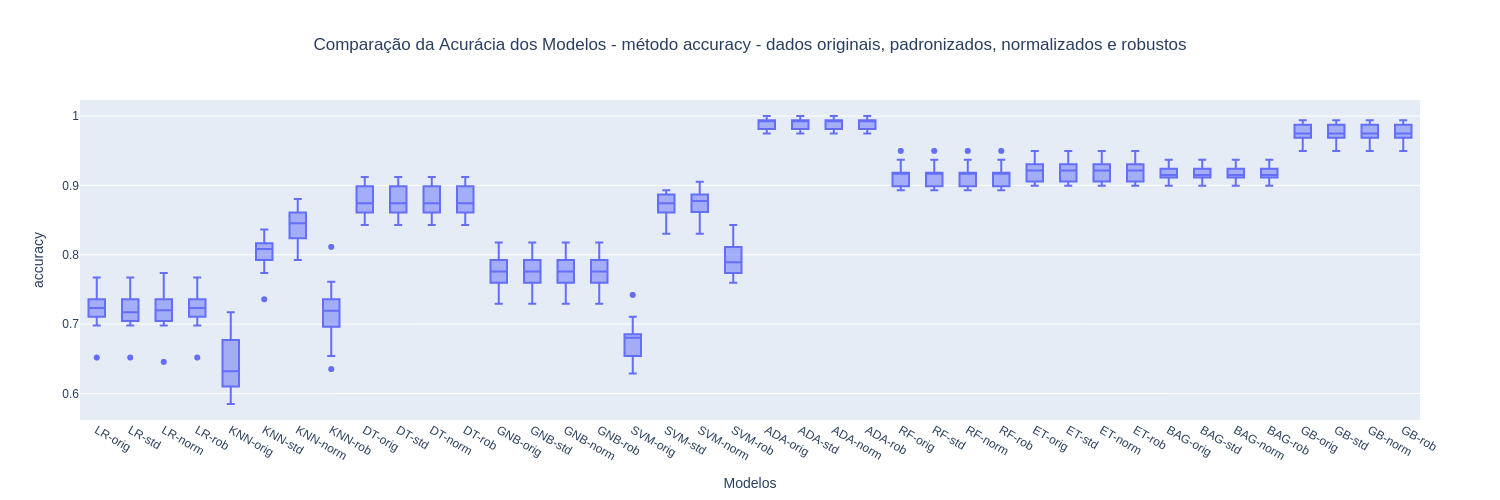

In [42]:
# boxplot de comparação dos modelos
fig = px.box(
    data_frame=pd.DataFrame(
        data=results, index=names
    ).transpose(),  # resultados individuais em linhas (index)
    y=names,
    title=f"Comparação da Acurácia dos Modelos - método {scoring} - dados originais, padronizados, normalizados e robustos",
    width=1500,
    height=500,
)
fig.update_layout(
    xaxis_title="Modelos",
    yaxis_title=scoring,
    title_x=0.5,
)
fig.show()

### Otimização de hiperparâmetros

In [48]:
# Tuning do AdaBoost
pipelines = []

# Definindo os componentes do pipeline
ada = ("ADA", AdaBoostClassifier(random_state=SEED))
standard_scaler = ("StandardScaler", StandardScaler())
min_max_scaler = ("MinMaxScaler", MinMaxScaler())
robust_scaler = ("RobustScaler", RobustScaler())

pipelines.append(("ADA-orig", Pipeline(steps=[ada])))
pipelines.append(("ADA-std", Pipeline(steps=[standard_scaler, ada])))
pipelines.append(("ADA-norm", Pipeline(steps=[min_max_scaler, ada])))
pipelines.append(("ADA-rob", Pipeline(steps=[robust_scaler, ada])))

param_grid = {
    "ADA__n_estimators": [250, 300, 350],
    "ADA__learning_rate": [1.0, 1.5, 2.0],
}

# Prepara e executa o GridSearchCV
for name, model in pipelines:
    grid = GridSearchCV(
        estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold
    )
    grid.fit(X_train, y_train)

    # imprime a melhor configuração
    print(
        f"Conjunto de dados: {name} - Acurácia: {grid.best_score_:.4f} - Parâmetros: {grid.best_params_}"
    )

Conjunto de dados: ADA-orig - Acurácia: 0.9918 - Parâmetros: {'ADA__learning_rate': 1.5, 'ADA__n_estimators': 300}
Conjunto de dados: ADA-std - Acurácia: 0.9918 - Parâmetros: {'ADA__learning_rate': 1.5, 'ADA__n_estimators': 300}
Conjunto de dados: ADA-norm - Acurácia: 0.9918 - Parâmetros: {'ADA__learning_rate': 1.5, 'ADA__n_estimators': 300}
Conjunto de dados: ADA-rob - Acurácia: 0.9918 - Parâmetros: {'ADA__learning_rate': 1.5, 'ADA__n_estimators': 300}


### Avaliação do modelo com os dados de teste

In [44]:
# avaliação do modelo com o conjunto de testes

# preparação do modelo
scaler = RobustScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = AdaBoostClassifier(random_state=SEED, n_estimators=300, learning_rate=1.5)
model.fit(rescaledX, y_train)

# estimativa da acurácia no conjunto de teste
rescaledTestX = scaler.transform(X_test)
predictions = model.predict(rescaledTestX)
print(f"Acuracia: {accuracy_score(y_test, predictions):.4f}")
print(f"Recall: {recall_score(y_test, predictions):.4f}")

Acuracia: 0.9899
Recall: 0.9854


In [45]:
# treinamento do modelo com o dataset completo
scaler = RobustScaler().fit(X)
rescaledX = scaler.transform(X)
model.fit(rescaledX, y)

,estimator,None
,n_estimators,300
,learning_rate,1.5
,algorithm,'deprecated'
,random_state,42


In [46]:
file_name = "adaboost_robust_model.pkl"
model_path = "../modelos/"

if os.path.exists(model_path):
    # salva o modelo no diretório especificado
    joblib.dump(model, os.path.join(model_path, file_name))
else:
    # salava o modelo na mesma pasta do notebook - para uso no Colab
    joblib.dump(model, file_name)

## Referências

BROWNLEE, Jason. **Machine Learning Mastery with Python Understand Your Data, Create Accurate Models and Work Projects End-To-End**. 1. ed. Austrália: Machine Learning Mastery, 2016.

GALLATIN, K.; ALBON, C.. **Machine Learning with Python Cookbook Practical Solutions from Preprocessing to Deep Learning**. 2. ed. O'Reilly, 2023.

GÉRON, Aurélien. **Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow**. 3. ed. Sebastopol, CA: O'Reilly Media, 2022.

MUKHOPADHYAY, Sayan. **Advanced Data Analytics Using Python**. Apress, 2018.